# Faraji 2021
----
"Tropical Pacific stalagmites are commonly affected by dating uncertainties because of their low
U concentration and/or elevated initial 230Th content."  

Faraji, M., Borsato, A., Frisia, S., Hellstrom, J.C., Lorrey, A., Hartland, A., Greig, A. and Mattey, D.P., 2021. Accurate dating of stalagmites from low seasonal contrast tropical Pacific climate using Sr 2D maps, fabrics and annual hydrological cycles. Scientific Reports, 11(1), p.2178.


# Elevated corections
----
Faraji et al. 2021 used lamina counting chronology to back-calculate the required initial thorium corrections that were needed to align the U-Th ages with laminae ages at the same horizons. 

In [8]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt


# Reported values and uncertainties of the initial thorium back-calcuated from laminae ages
Faraji_val_est = np.array([8.05, 6.00, 5.98, 6.63, 7.74, 6.55, 6.01, 6.21, 6.87, 4.88])
Faraji_err_est = np.array([0.24, 0.25, 0.27, 0.25, 0.18, 0.21, 0.50, 0.46, 0.27, 0.97])

In [9]:
# IBIS example
import ibis 
from ibis import IBIS_Main

# Meta Dictionary with all information - users can tune to their liking here

In [10]:
# Meta Dictionary with all information - users can tune to their liking here

_META = dict(
        # depth handling
        depth_increases_down=True,
        depth_tol=0.0,  # 0 => no rounding

        # boutique sampler
        fraction_det=0.2,
        r02_clip_lo=0.001,
        r02_clip_hi=1000.0,

        # r02 max bound from data (IMPORTANT)
        r02_max_k_sigma=3.0,  # use (r08+kσ)/(r28-kσ)

        # r02 relative uncertainty proposal
        r02_err_mode="halfnorm",   # "fixed"|"uniform"|"halfnorm"
        r02_rel_err=0.25,
        r02_rel_min=0.005,
        r02_rel_max=1.0,

        # validity gates
        age_sigma_gate=3.0,
        age_eps=1e-12,

        # sigma cheating prevention (EB): default False
        use_r02_in_sigma=True,

        # batch sampler controls
        batch_size = 100,
        max_batches=50,
        keep_frac=0.08,
        keep_factor=8,

        # layer windows
        neighbors=1,

        # pair weighting
        pair_weight_mode="exp",   # "none"|"exp"|"power"
        pair_tau_layers=2.0,
        pair_alpha=1.0,
        min_pair_weight=1e-6,

        # prior mixture
        global_mass=0.7,
        n_samples_global=4000,
        n_samples_layer=1000,

        # KDE fit controls
        kde_beta=0.7,
        bw_grid=None,
        cv=5,
        bw_subsample=3000,
        grid_n=1200,
        hi_pct=99.9,
        floor_pdf=1e-12,
    Verbose = True
    )

# Create an IBIS instance 
IBIS requirement minimum
<br>
(1) Pathway to datafile
<br>
(2) Filename
<br>
Extras
<br>
(3) MCMC_samples - how many iterations for the post burn in. 
<br>
(4) MCMC_burn_in - how many samples for burn_in (step adaption only occur in this phase)
<br>
(5) MCMC_Start_samples - define total number of iterations for strat portion (burn-in for this phase is 50% of the total
<br>
(6) n_chains - how many chains to run
<br>
(7) Start_from_pickles - True/False if True will scan folders for last position of chain and restart from that position
<br>
(8) show_bird - True/False if True the bird will print if requirements are satisfied
<br>
(9) method - thoth - this is the method for the determination of the prior distribution
<br>
(10) strat_resolution - model density of the age-depth strat part of the model process
<br>
(11) diction_meta - meta data for model so users can adapt parameters if needed. 

In [11]:

mm = IBIS_Main.IBIS('/Users/johncarter/Detrital Analysis/Desktop/Faraji_2021_data.xlsx',
    sample_name='Faraji_2021_ibis',          
    MCMC_samples=1000000,
    MCMC_burn_in=500000,
    MCMC_Strat_samples=300000,
    n_chains=3,
    Start_from_pickles=True, 
    show_bird=True, 
    method='thoth',
    strat_resolution=100, 
                    diction_meta= _META,
)


Data loaded successfully from /Users/johncarter/Detrital Analysis/Desktop/Faraji_2021_data.xlsx (Excel)
All results will save to: /Users/johncarter/Desktop/Faraji_2021_ibis_folder

                 ==============    ==========     =============   ============
                        =          =         =          =         =
                        =          =          =         =         =
                        =          =          =         =         =
                        =          =         =          =         =
                        =          ==========           =         ============
                        =          =         =          =                    =
                        =          =          =         =                    =
                        =          =          =         =                    =
                        =          =         =          =                    =
                  =============    ==========      ============   =======

In [12]:
# Part 1 - set up the MCMC

In [13]:
#mm.Get_IBIS_Bounds();

In [14]:
mm.Set_Up_MCMC(); 

Bounds and uncertainties file exists and is loaded.
♻️  Loaded existing Thorium prior from
/Users/johncarter/Desktop/Faraji_2021_ibis_folder/Faraji_2021_ibis_prior.pkl


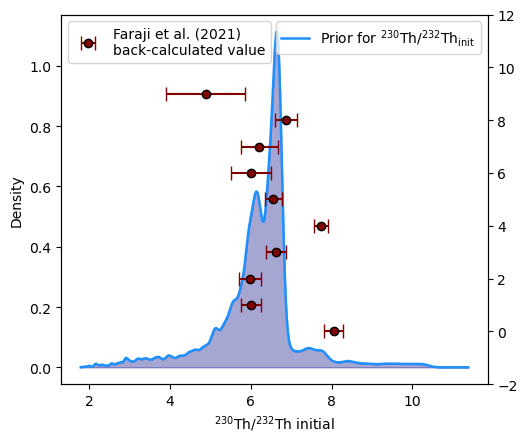

In [15]:
# Plot of the IBIS derived prior using composite 
# global and neighbour estimates
# for comparison "True" are overlain
fig, ax = mm.Plot_Priors()
ax2 =ax.twinx() # Twin x-axis
ax2.errorbar(x = Faraji_val_est, 
             xerr = Faraji_err_est, 
             y = np.arange(Faraji_err_est.size), 
             fmt = 'o', 
             capsize = 5, color = 'maroon', 
            label = 'Faraji et al. (2021)\nback-calculated value', 
            markeredgecolor= 'k')
ax.legend(loc = 'upper right')
ax2.set_ylim(-2, 12)
ax2.legend(loc = 'upper left')

In [16]:
# Run initial thorium
mm.Run_MCMC()

Loaded starting θ from pickles


Chain 0:  42%|████▏     | 623658/1500000 [01:48<02:34, 5667.72it/s]


[i=5000] acc=0.307  rej(invθ)=0 rej(age_nan)=2 rej(lp_nan)=155 accepted=1533 sat_frac=0.000
worst_adj_violation: i=5, j=6, Δ=-0.677914, z=-0.0182991
acc-by-family: Th0=0.249  U234=0.278  Th230=0.430  Th232=0.647


[i=10000] acc=0.300  rej(invθ)=0 rej(age_nan)=4 rej(lp_nan)=283 accepted=2998 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.253  U234=0.276  Th230=0.403  Th232=0.619


[i=15000] acc=0.294  rej(invθ)=0 rej(age_nan)=6 rej(lp_nan)=443 accepted=4412 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.246  U234=0.278  Th230=0.390  Th232=0.608


[i=20000] acc=0.289  rej(invθ)=0 rej(age_nan)=7 rej(lp_nan)=593 accepted=5787 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.243  U234=0.282  Th230=0.379  Th232=0.592


[i=25000] acc=0.286  rej(invθ)=0 rej(age_nan)=8 rej(lp_nan)=710 accepted=7157 sat_frac=0.000
worst_adj_violation: i=3, j=4, Δ=-7.59158, z=-0.0781512
acc-by-family: Th0=0.247  U234=0.276  Th230=0.370  Th232=0.576


[i=30000] acc=0.284

Chain 0:  69%|██████▊   | 1028150/1500000 [02:59<01:23, 5626.46it/s]


[i=420000] acc=0.232  rej(invθ)=0 rej(age_nan)=144 rej(lp_nan)=12574 accepted=97248 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.248  U234=0.260  Th230=0.287  Th232=0.346


[i=425000] acc=0.231  rej(invθ)=0 rej(age_nan)=144 rej(lp_nan)=12711 accepted=98354 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.249  U234=0.260  Th230=0.286  Th232=0.345


[i=430000] acc=0.231  rej(invθ)=0 rej(age_nan)=144 rej(lp_nan)=12853 accepted=99453 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.249  U234=0.260  Th230=0.286  Th232=0.344


[i=435000] acc=0.231  rej(invθ)=0 rej(age_nan)=148 rej(lp_nan)=13003 accepted=100551 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.249  U234=0.261  Th230=0.286  Th232=0.344


[i=440000] acc=0.231  rej(invθ)=0 rej(age_nan)=148 rej(lp_nan)=13165 accepted=101634 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.249  U234=0.261  Th230=0.286  Th232=0.343


[i=445000] acc=0.231  rej(invθ)=0 rej(age_nan)=

Chain 0:  95%|█████████▌| 1429496/1500000 [04:10<00:12, 5788.91it/s]


[i=825000] acc=0.223  rej(invθ)=0 rej(age_nan)=317 rej(lp_nan)=24837 accepted=184158 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.249  U234=0.255  Th230=0.272  Th232=0.315


[i=830000] acc=0.223  rej(invθ)=0 rej(age_nan)=318 rej(lp_nan)=24974 accepted=185218 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.249  U234=0.255  Th230=0.272  Th232=0.314


[i=835000] acc=0.223  rej(invθ)=0 rej(age_nan)=321 rej(lp_nan)=25134 accepted=186239 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.249  U234=0.255  Th230=0.272  Th232=0.314


[i=840000] acc=0.223  rej(invθ)=0 rej(age_nan)=326 rej(lp_nan)=25254 accepted=187284 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.249  U234=0.255  Th230=0.271  Th232=0.314


[i=845000] acc=0.223  rej(invθ)=0 rej(age_nan)=326 rej(lp_nan)=25383 accepted=188394 sat_frac=0.000
worst_adj_violation: i=3, j=4, Δ=-5.53743, z=-0.0570048
acc-by-family: Th0=0.249  U234=0.255  Th230=0.271  Th232=0.314


[i=850000] acc

In [20]:
# Save summary to folder
mm.SaveSummary(); 

IBIS summary saved to: /Users/johncarter/Desktop/Faraji_2021_ibis_folder/Faraji_2021_ibis_ibis_summary.csv
Summary saved to Faraji_2021_ibis_ibis_summary.csv


In [21]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
df_summary = pd.read_csv("/Users/johncarter/Desktop/Faraji_2021_ibis_folder/Faraji_2021_ibis_ibis_summary.csv")

In [22]:
# delta
# point estimates
ibis = df_summary['initial thorium'].to_numpy()
far  = np.asarray(Faraji_val_est)  # same length as df_summary
depth = df_summary['Depth_Meas'].to_numpy()

# choose which IBIS 1σ to use based on which side Faraji lies
ibis_sig_lo = df_summary['Th0_err_lo68'].to_numpy()
ibis_sig_hi = df_summary['Th0_err_hi68'].to_numpy()
ibis_sig_side = np.where(far < ibis, ibis_sig_lo, ibis_sig_hi)

# Faraji 1σ 
far_sig = np.asarray(Faraji_err_est)

# delta and uncertainty (assuming independent)
delta = far - ibis
delta_sig = np.hypot(far_sig,ibis_sig_side)


Text(0.5, 0, 'Δ = Faraji − IBIS')

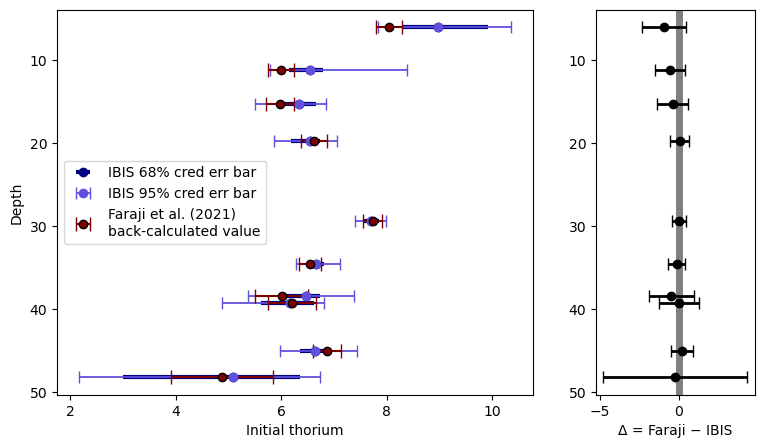


[i=1230000] acc=0.221  rej(invθ)=0 rej(age_nan)=454 rej(lp_nan)=36916 accepted=271774 sat_frac=0.000
worst_adj_violation: i=5, j=6, Δ=-1.2717, z=-0.0343274
acc-by-family: Th0=0.250  U234=0.255  Th230=0.267  Th232=0.304


[i=1235000] acc=0.221  rej(invθ)=0 rej(age_nan)=456 rej(lp_nan)=37093 accepted=272805 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.250  U234=0.255  Th230=0.267  Th232=0.304


[i=1240000] acc=0.221  rej(invθ)=0 rej(age_nan)=457 rej(lp_nan)=37234 accepted=273870 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.250  U234=0.255  Th230=0.266  Th232=0.304


[i=1245000] acc=0.221  rej(invθ)=0 rej(age_nan)=457 rej(lp_nan)=37398 accepted=274954 sat_frac=0.000
worst_adj_violation: none
acc-by-family: Th0=0.250  U234=0.255  Th230=0.266  Th232=0.304


[i=1250000] acc=0.221  rej(invθ)=0 rej(age_nan)=458 rej(lp_nan)=37558 accepted=276072 sat_frac=0.000
worst_adj_violation: i=3, j=4, Δ=-5.0101, z=-0.0515763
acc-by-family: Th0=0.250  U234=0.255  Th230=0.

In [23]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,2, figsize = (9, 5), 
                     gridspec_kw={"width_ratios": [3, 1]})

ax[0].errorbar(y = df_summary['Depth_Meas'], 
            x = df_summary['initial thorium'],
            xerr = np.vstack([df_summary['Th0_err_lo68'], 
                             df_summary['Th0_err_hi68']]),
              fmt = 'o', lw = 3, 
            color = 'navy',
              label = 'IBIS 68% cred err bar')

ax[0].errorbar(y = df_summary['Depth_Meas'], 
            x = df_summary['initial thorium'],
            xerr = np.vstack([df_summary['Th0_err_lo95'], 
                             df_summary['Th0_err_hi95']]),
              fmt = 'o', lw = 1.3, 
              label = 'IBIS 95% cred err bar', 
           capsize = 4, 
           color = '#6050DC')

ax[0].errorbar(x = Faraji_val_est, 
             xerr = Faraji_err_est, 
             y = df_summary['Depth_Meas'], 
             fmt = 'o', 
             capsize = 5, color = 'maroon', 
            label = 'Faraji et al. (2021)\nback-calculated value', 
            markeredgecolor= 'k')

ax[0].legend()
ax[0].invert_yaxis()
ax[0].set_ylabel('Depth')
ax[0].set_xlabel('Initial thorium')


# plot on ax[1]
ax[1].errorbar(
    x=delta, y=depth,
    xerr=delta_sig * 2,
    fmt='o', lw=2, capsize=4,
    color='black', zorder = 1000
)
ax[1].axvline(0, lw=5, color='0.5')
ax[1].invert_yaxis()
ax[1].set_xlabel('Δ = Faraji − IBIS')